reservation wage = 11.186440677966102


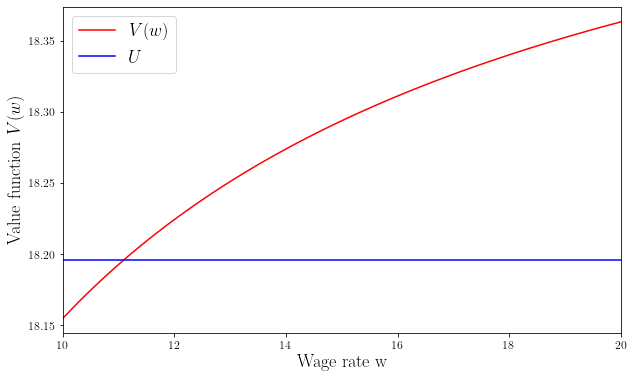

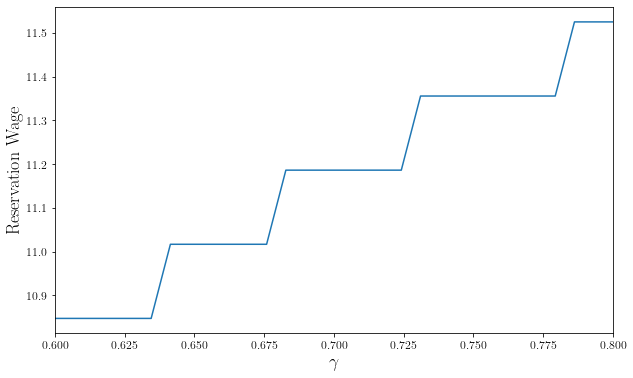

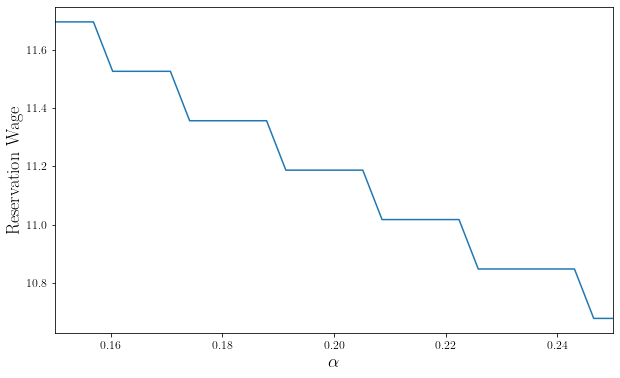

In [ ]:
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt

# TeX Support for plots
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

def util(x,sigma):

    utility = (x**(1.0-sigma)-1.0)/(1.0-sigma)

    return utility

#-------------------------------------------------------------------------------
#               Function: Beta-binomial distribution
#-------------------------------------------------------------------------------

def betabinomial(n, a, b):

    k = np.linspace(0, n, n + 1)
    probs = sp.binom(n, k)*sp.beta(k + a, n - k + b) / sp.beta(a, b)

    return probs

#-------------------------------------------------------------------------------
#               Function: Main iterative loop
#-------------------------------------------------------------------------------

def vfi_mccall_extended(wages, probs, v_guess, u_guess, betta, c, alpha, gamma, maxiter=10000, tol=10e-6):

    v_new = np.zeros(len(wages))
    u_new = 0.0

    # Value Function Iteration
    for iter1 in range(maxiter):

        # Calculate the new V given your guess and the wage distribution
        v_new = util(wages,sigma) + betta*((1.0-alpha)*v_guess+alpha*u_guess)
        u_new = util(c,sigma) + betta*(1.0-gamma)*u_guess + betta*gamma*np.sum(np.maximum(u_guess,v_guess)* probs)
        
        # Calculate the distance between successive iterations
        # The distance here is the maximum element of the absolute difference between successive iterates
        metric_v = np.amax(np.abs(v_new-v_guess))
        metric_u = np.abs(u_new-u_guess)
        metric = np.maximum(metric_v,metric_u)
        
        # Print the distance
        # print(iter1, metric)
        
        # If the distance is sufficiently small, break the loop
        if metric < tol:
            break

        # Adjust the guess
        v_guess[:] = v_new
        u_guess = u_new
        #v_guess = np.copy(v_new)

    # calculate the reservation wage
    reservation_wage = wages[np.argmax(u_new<v_new)]

    return reservation_wage,v_new,u_new

#-------------------------------------------------------------------------------
#               Solution of the basic McCall model
#-------------------------------------------------------------------------------

# Generate a wage distribution with
# 60 different wages ranging from 10.0 to 20.0
n = 60
w_min = 10.0
w_max = 20.0

# Beta-binomial distribution parameters
a = 600.0
b = 400.0

# Generate the distribution
wages = np.linspace(w_min,w_max,n)
probs = betabinomial(n-1,a,b)

# Parameters
betta = 0.95
c = 6.0
alpha = 0.2
gamma = 0.7
sigma = 2.0

# calculate reservation wage and the value function\n",
result = vfi_mccall_extended(wages, probs, np.zeros(n), 0.0, betta, c, alpha, gamma)

print("reservation wage =", result[0])

# Plot the value function for given wages

# Set up a figure
fig,ax=plt.subplots(figsize=(10,6))
ax.plot(wages, result[1], color='red', label='$V(w)$')
ax.plot(wages, result[2]*np.ones(n), color='blue', label='$U$')
plt.xlim((10,20))
plt.rc('axes', titlesize=18)
plt.rc('axes', labelsize=18)
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.legend(loc='upper left',fontsize=18)
ax.set_xlabel('Wage rate w', fontsize=18)
ax.set_ylabel('Value function $V(w)$', fontsize=18)
plt.show()

##============================================================================##
#                       Comparative Statics
##============================================================================##

n_gam = 30
res_wage_gam = np.zeros(n_gam)
gam_seq = np.linspace(0.6,0.8,n_gam)

for igam in range(n_gam):
    res_wage_gam[igam],_,_ = vfi_mccall_extended(wages, probs, np.zeros(n), 0.0, betta, c, alpha, gam_seq[igam])

fig,ax=plt.subplots(figsize=(10,6))
ax.plot(gam_seq, res_wage_gam)
plt.xlim((0.6,0.8))
plt.rc('axes', titlesize=18)
plt.rc('axes', labelsize=18)
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.set_xlabel('$\gamma$', fontsize=18)
ax.set_ylabel('Reservation Wage', fontsize=18)
plt.show()
fig.savefig("res_wage_gamma.pdf", bbox_inches='tight')

n_alp = 30
res_wage_alp = np.zeros(n_alp)
alp_seq = np.linspace(0.15,0.25,n_alp)

for ialp in range(n_alp):
    res_wage_alp[ialp],_,_ = vfi_mccall_extended(wages, probs, np.zeros(n), 0.0, betta, c, alp_seq[ialp], gamma)

fig,ax=plt.subplots(figsize=(10,6))
ax.plot(alp_seq, res_wage_alp)
plt.xlim((0.15,0.25))
plt.rc('axes', titlesize=18)
plt.rc('axes', labelsize=18)
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.set_xlabel('$\\alpha$', fontsize=18)
ax.set_ylabel('Reservation Wage', fontsize=18)
plt.show()
fig.savefig("res_wage_alpha.pdf", bbox_inches='tight')

res_wage_alp_gam = np.zeros((n_alp,n_gam))

for ialp in range(n_alp):
    for igam in range(n_gam):
        res_wage_alp_gam[ialp,igam] = vfi_mccall_extended(wages, probs, np.zeros(n), 0.0, betta, c, alp_seq[ialp], gam_seq[igam])[0]

fig,ax=plt.subplots(figsize=(12,7))

cs1=ax.contourf(gam_seq,alp_seq,res_wage_alp_gam,alpha=0.75)
ctr1=ax.contour(gam_seq,alp_seq,res_wage_alp_gam,alpha=0.75)

plt.clabel(ctr1, inline=1, fontsize=13)
plt.colorbar(cs1, ax=ax)
ax.set_title("Reservation Wage", fontsize=20)
ax.set_ylabel("$\\alpha$", fontsize=20)
ax.set_xlabel("$\\gamma$", fontsize=20)
ax.ticklabel_format(useOffset=False)
plt.show()
fig.savefig("res_wage_contour.pdf", bbox_inches='tight')
